# Heart Disease UCI Dataset - Exploratory Data Analysis

## MLOps Assignment - Task 1: Data Acquisition & EDA

This notebook performs comprehensive exploratory data analysis on the UCI Heart Disease dataset.

### Dataset Information
- **Source**: UCI Machine Learning Repository
- **Samples**: 303 patients from Cleveland Clinic
- **Features**: 14 attributes (13 features + 1 target)
- **Task**: Binary classification (presence/absence of heart disease)

### Contents
1. Data Loading and Inspection
2. Missing Value Analysis
3. Statistical Summary
4. Feature Distributions
5. Correlation Analysis
6. Target Class Distribution
7. Feature Analysis by Target Class

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Data Loading and Inspection

In [3]:
# Define feature names based on UCI documentation
FEATURE_NAMES = [
    'age',       # Age in years
    'sex',       # Sex (1 = male; 0 = female)
    'cp',        # Chest pain type (1-4)
    'trestbps',  # Resting blood pressure (mm Hg)
    'chol',      # Serum cholesterol (mg/dl)
    'fbs',       # Fasting blood sugar > 120 mg/dl
    'restecg',   # Resting ECG results (0-2)
    'thalach',   # Maximum heart rate achieved
    'exang',     # Exercise induced angina
    'oldpeak',   # ST depression induced by exercise
    'slope',     # Slope of peak exercise ST segment
    'ca',        # Number of major vessels (0-3)
    'thal',      # Thalassemia
    'target'     # Heart disease diagnosis
]

# Load the dataset
df = pd.read_csv(
    '../heart_disease_data/processed.cleveland.data',
    names=FEATURE_NAMES,
    na_values=['?']
)

print(f'Dataset loaded: {df.shape[0]} samples, {df.shape[1]} columns')
print(f'\nFeatures: {FEATURE_NAMES[:-1]}')
print(f'Target: {FEATURE_NAMES[-1]}')

Dataset loaded: 303 samples, 14 columns

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target: target


In [4]:
# Display first few rows
print('First 10 rows of the dataset:')
df.head(10)

First 10 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [5]:
# Data types and info
print('Data Types and Memory Usage:')
print('=' * 50)
df.info()

Data Types and Memory Usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## 2. Missing Value Analysis

In [6]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
})

print('Missing Value Analysis:')
print('=' * 50)
print(missing_df[missing_df['Missing Values'] > 0])
print(f'\nTotal missing values: {missing.sum()}')
print(f'Percentage of data with missing values: {(df.isnull().any(axis=1).sum() / len(df)) * 100:.2f}%')

Missing Value Analysis:
      Missing Values  Percentage
ca                 4    1.320132
thal               2    0.660066

Total missing values: 6
Percentage of data with missing values: 1.98%


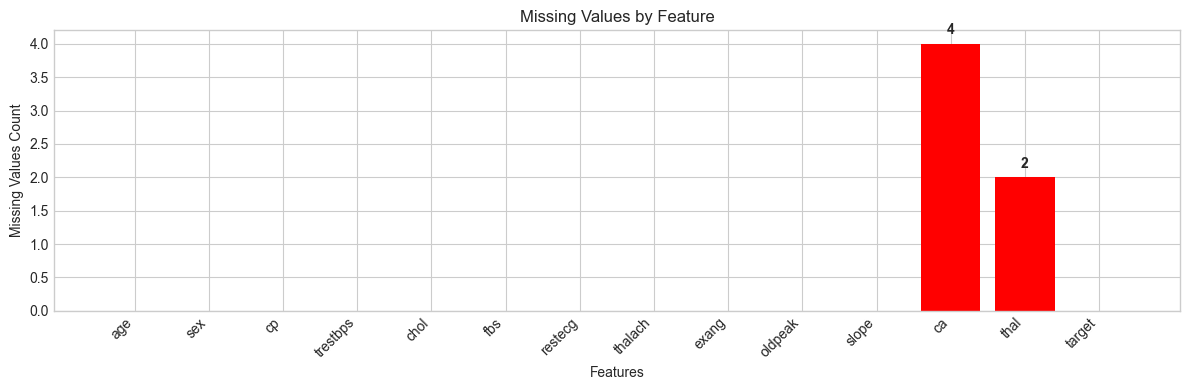

In [7]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 4))
missing_data = df.isnull().sum()
colors = ['red' if x > 0 else 'green' for x in missing_data]
bars = ax.bar(missing_data.index, missing_data.values, color=colors)
ax.set_xlabel('Features')
ax.set_ylabel('Missing Values Count')
ax.set_title('Missing Values by Feature')
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar, val in zip(bars, missing_data.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Handle missing values
print('Handling Missing Values...')

# For 'ca' column - fill with median
if df['ca'].isnull().any():
    median_ca = df['ca'].median()
    df['ca'].fillna(median_ca, inplace=True)
    print(f"'ca' - filled {df['ca'].isnull().sum()} values with median: {median_ca}")

# For 'thal' column - fill with mode
if df['thal'].isnull().any():
    mode_thal = df['thal'].mode()[0]
    df['thal'].fillna(mode_thal, inplace=True)
    print(f"'thal' - filled with mode: {mode_thal}")

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

Handling Missing Values...
'ca' - filled 0 values with median: 0.0
'thal' - filled with mode: 3.0

Remaining missing values: 0


## 3. Statistical Summary

In [9]:
# Convert target to binary (0 = no disease, 1 = disease)
df['target'] = (df['target'] > 0).astype(int)

print('Target variable converted to binary:')
print('0 = No Heart Disease')
print('1 = Heart Disease Present')

Target variable converted to binary:
0 = No Heart Disease
1 = Heart Disease Present


In [10]:
# Descriptive statistics
print('Descriptive Statistics:')
print('=' * 80)
df.describe().round(2)

Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.66,4.72,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


In [11]:
# Separate features by type
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print('Feature Classification:')
print(f'Numerical Features: {numerical_features}')
print(f'Categorical Features: {categorical_features}')

Feature Classification:
Numerical Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 4. Feature Distributions

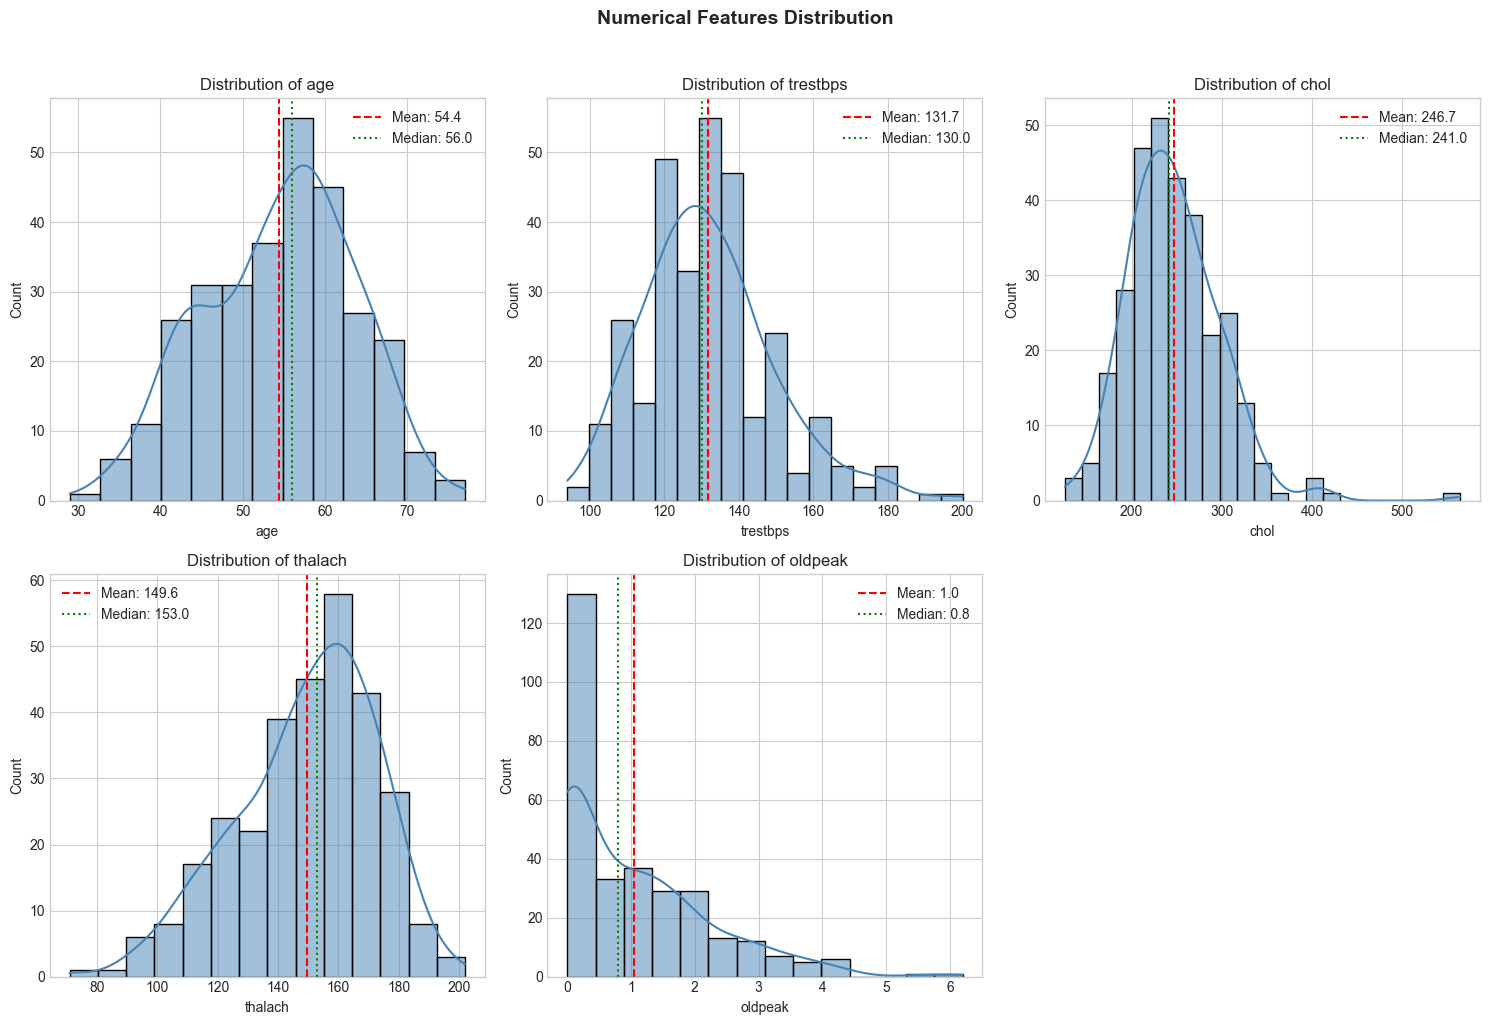

In [12]:
# Distribution of numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    sns.histplot(data=df, x=feature, kde=True, ax=ax, color='steelblue')
    ax.axvline(df[feature].mean(), color='red', linestyle='--', label=f'Mean: {df[feature].mean():.1f}')
    ax.axvline(df[feature].median(), color='green', linestyle=':', label=f'Median: {df[feature].median():.1f}')
    ax.set_title(f'Distribution of {feature}')
    ax.legend()

# Hide empty subplot
axes[-1].set_visible(False)

plt.suptitle('Numerical Features Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

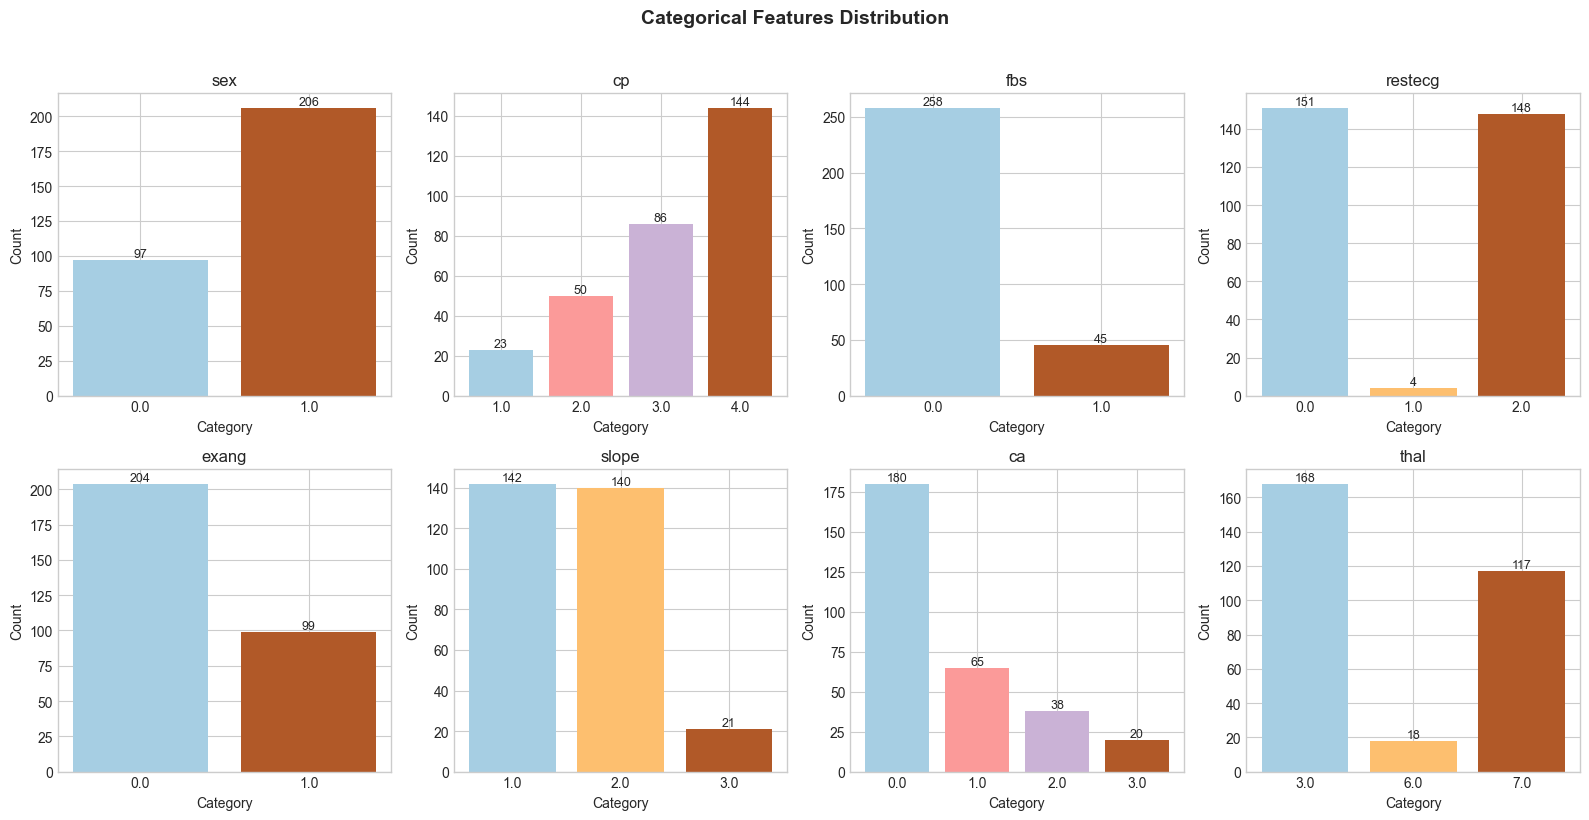

In [13]:
# Distribution of categorical features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    ax = axes[idx]
    value_counts = df[feature].value_counts().sort_index()
    bars = ax.bar(value_counts.index.astype(str), value_counts.values, color=plt.cm.Paired(np.linspace(0, 1, len(value_counts))))
    ax.set_title(f'{feature}')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Categorical Features Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

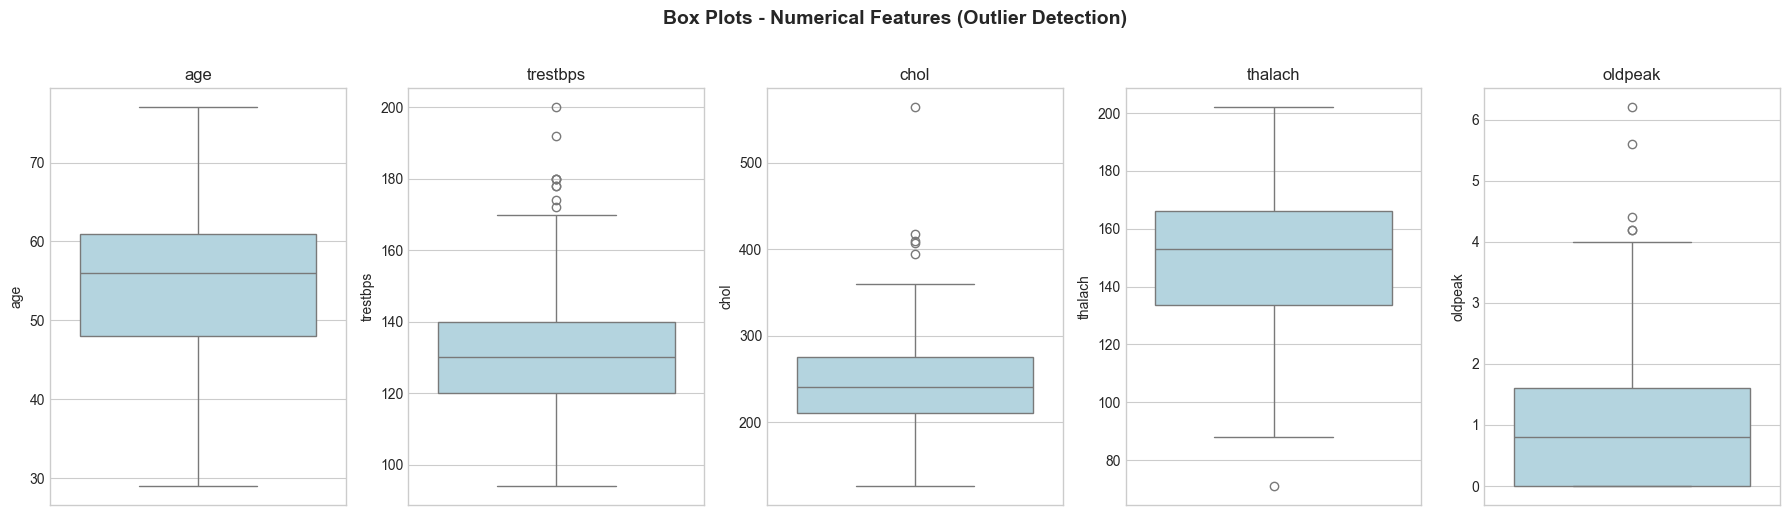

In [14]:
# Box plots for numerical features
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    sns.boxplot(data=df, y=feature, ax=ax, color='lightblue')
    ax.set_title(f'{feature}')

plt.suptitle('Box Plots - Numerical Features (Outlier Detection)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

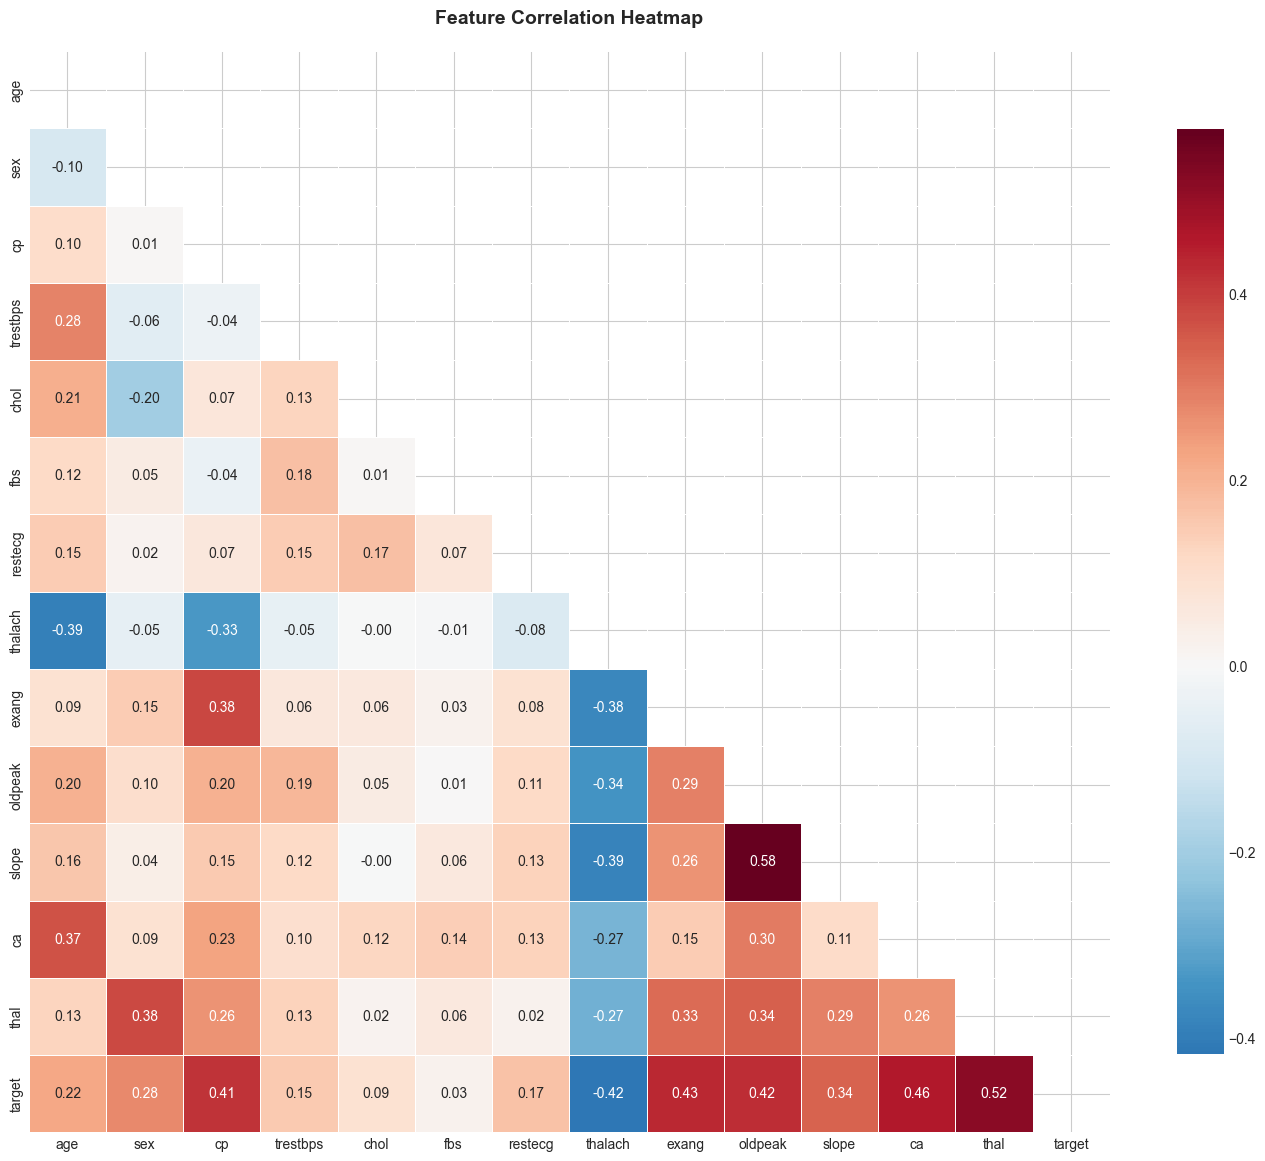

In [15]:
# Correlation matrix
correlation_matrix = df.corr()

# Create correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

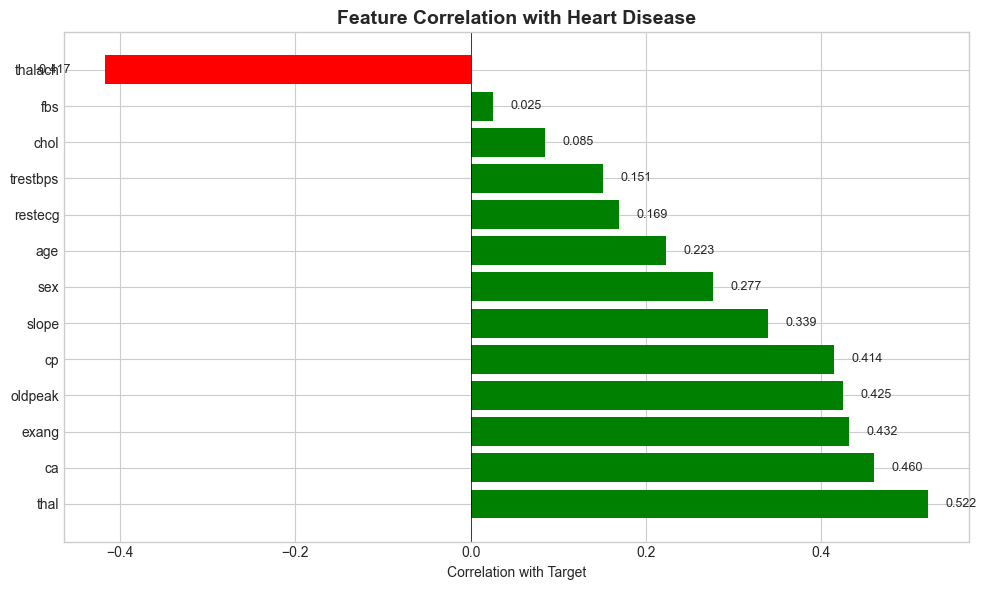


Features most correlated with Heart Disease:
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


In [16]:
# Correlation with target variable
target_correlation = correlation_matrix['target'].drop('target').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in target_correlation.values]
bars = ax.barh(target_correlation.index, target_correlation.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlation with Target')
ax.set_title('Feature Correlation with Heart Disease', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, target_correlation.values):
    ax.text(val + 0.02 if val > 0 else val - 0.08, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../screenshots/target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeatures most correlated with Heart Disease:')
print(target_correlation)

## 6. Target Class Distribution

In [17]:
# Class distribution
class_counts = df['target'].value_counts()
class_percentages = df['target'].value_counts(normalize=True) * 100

print('Target Class Distribution:')
print('=' * 40)
print(f'No Heart Disease (0): {class_counts[0]} samples ({class_percentages[0]:.1f}%)')
print(f'Heart Disease (1):    {class_counts[1]} samples ({class_percentages[1]:.1f}%)')
print(f'\nClass Imbalance Ratio: {class_counts[0]/class_counts[1]:.2f}:1')

Target Class Distribution:
No Heart Disease (0): 164 samples (54.1%)
Heart Disease (1):    139 samples (45.9%)

Class Imbalance Ratio: 1.18:1


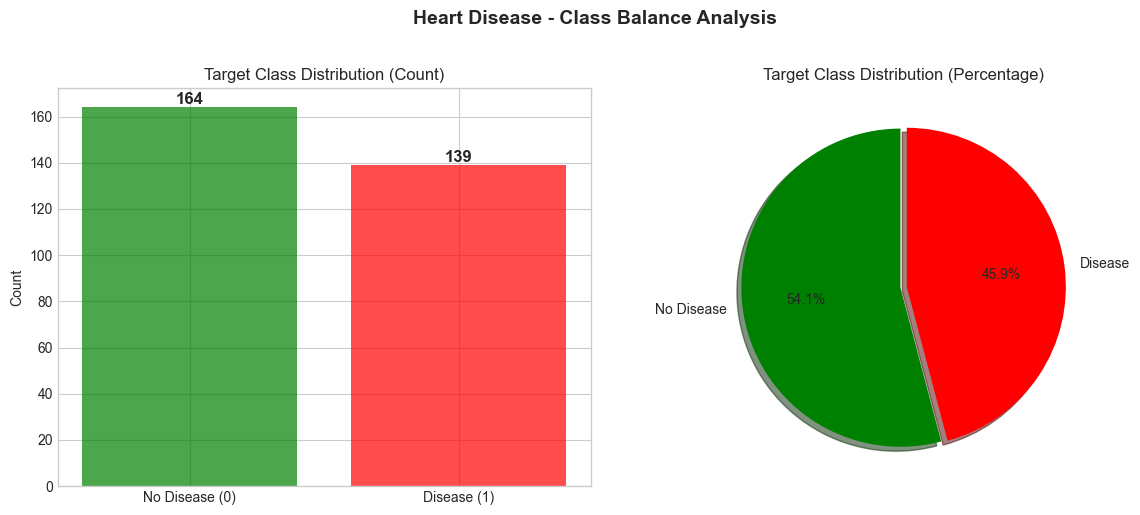

In [18]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
ax1 = axes[0]
bars = ax1.bar(['No Disease (0)', 'Disease (1)'], class_counts.values, 
               color=['green', 'red'], alpha=0.7)
ax1.set_ylabel('Count')
ax1.set_title('Target Class Distribution (Count)')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
ax2 = axes[1]
colors = ['green', 'red']
explode = (0.02, 0.02)
ax2.pie(class_counts.values, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
        colors=colors, explode=explode, shadow=True, startangle=90)
ax2.set_title('Target Class Distribution (Percentage)')

plt.suptitle('Heart Disease - Class Balance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Analysis by Target Class

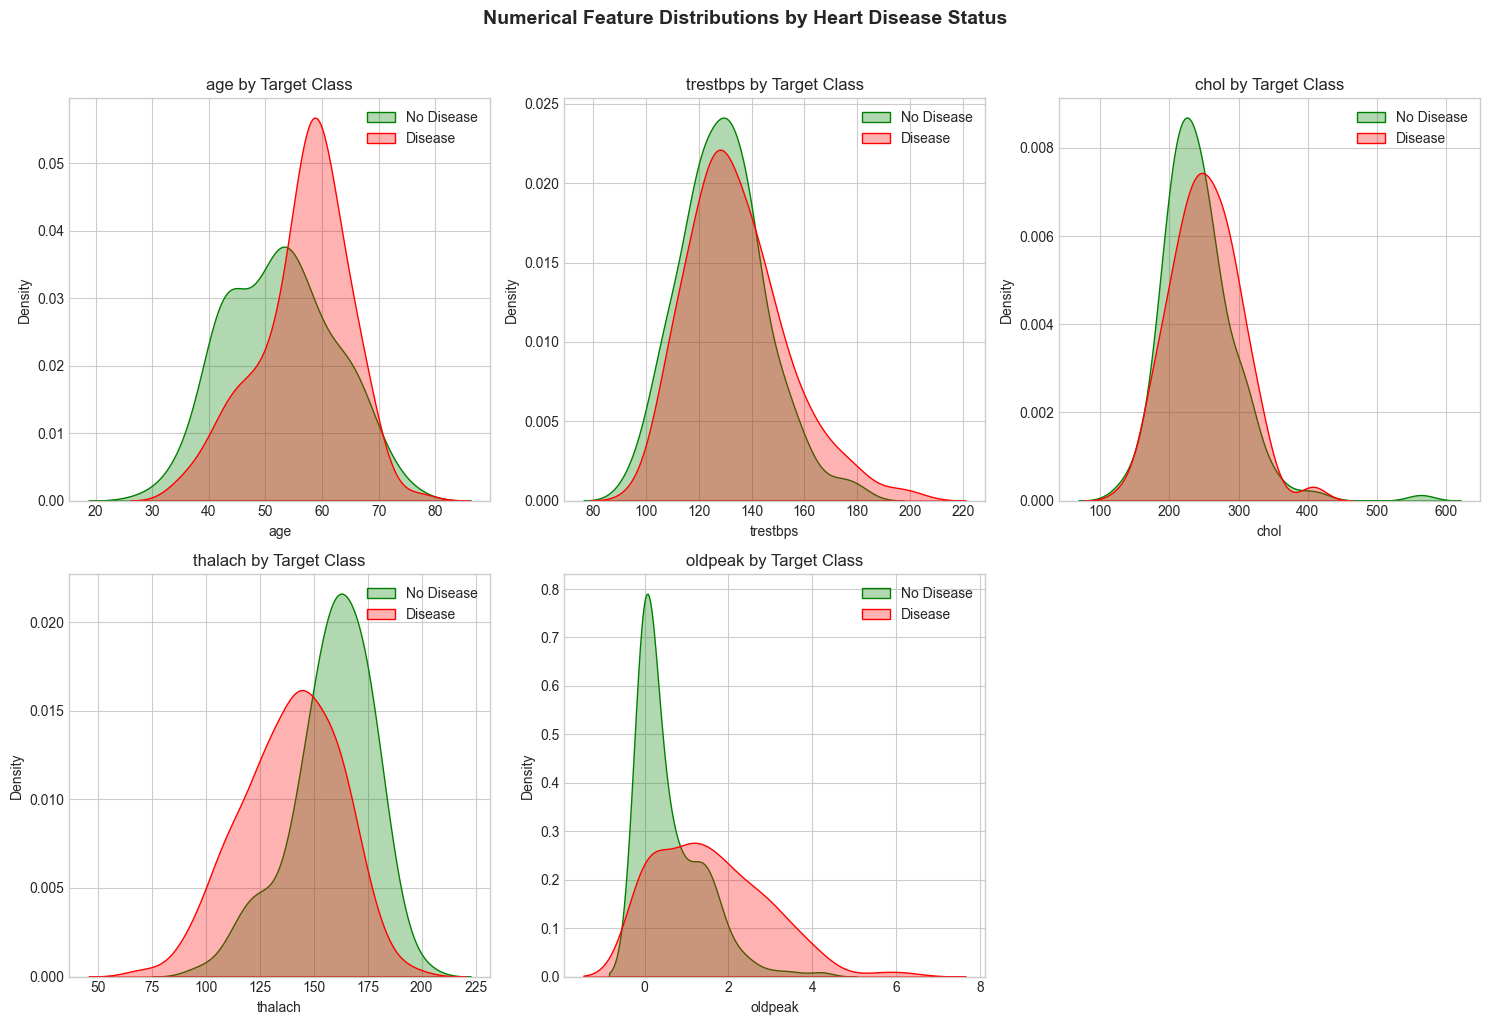

In [19]:
# Numerical features by target class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    for target_val, color, label in [(0, 'green', 'No Disease'), (1, 'red', 'Disease')]:
        subset = df[df['target'] == target_val][feature]
        sns.kdeplot(data=subset, ax=ax, color=color, label=label, fill=True, alpha=0.3)
    ax.set_title(f'{feature} by Target Class')
    ax.legend()

axes[-1].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Heart Disease Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/features_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

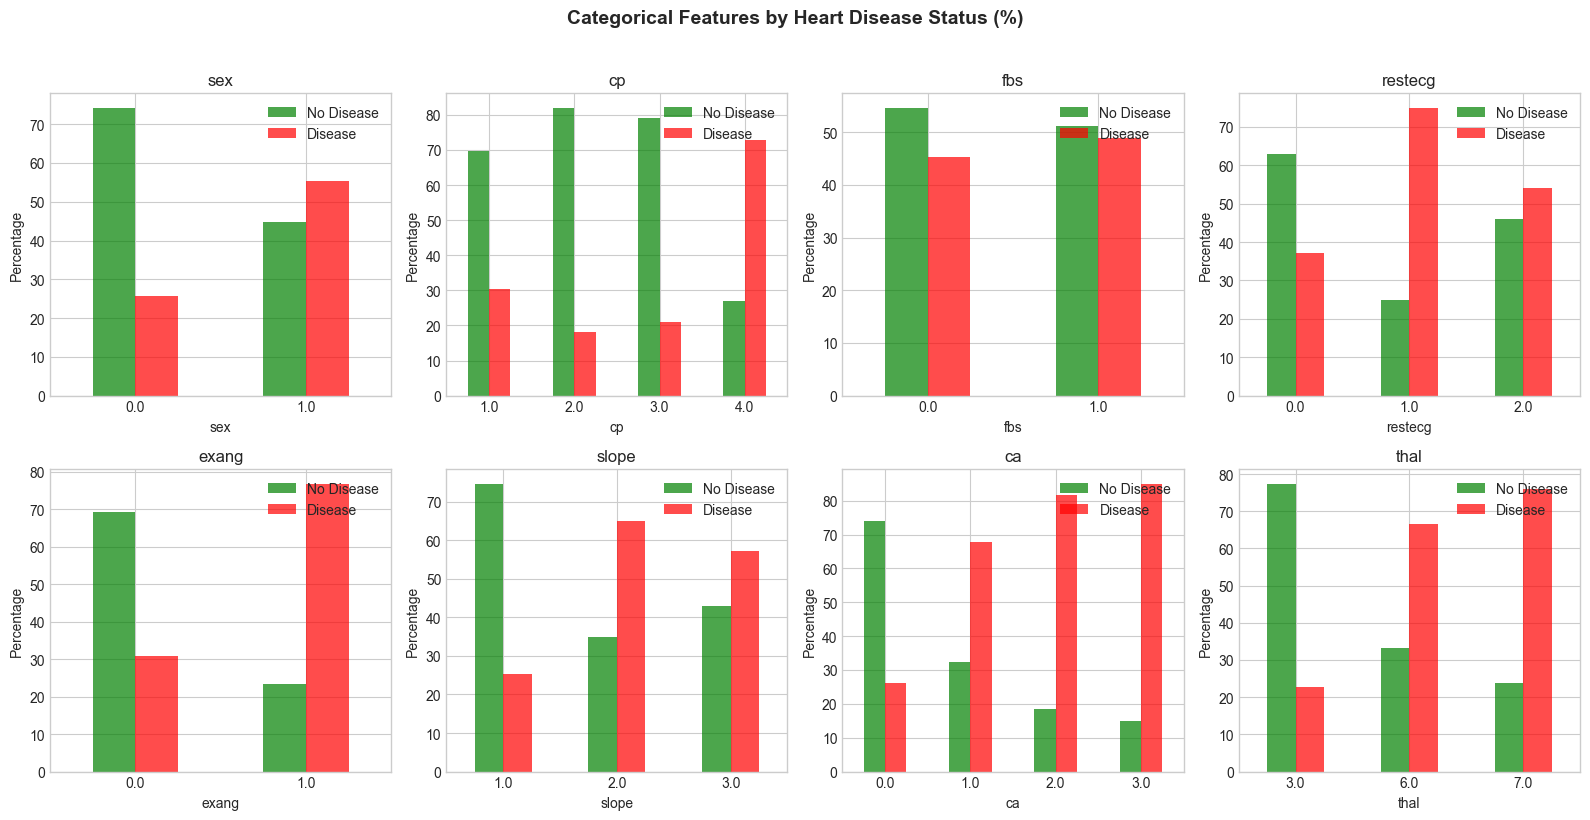

In [20]:
# Categorical features by target class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    ax = axes[idx]
    cross_tab = pd.crosstab(df[feature], df['target'], normalize='index') * 100
    cross_tab.plot(kind='bar', ax=ax, color=['green', 'red'], alpha=0.7)
    ax.set_title(f'{feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Percentage')
    ax.legend(['No Disease', 'Disease'], loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.suptitle('Categorical Features by Heart Disease Status (%)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/categorical_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

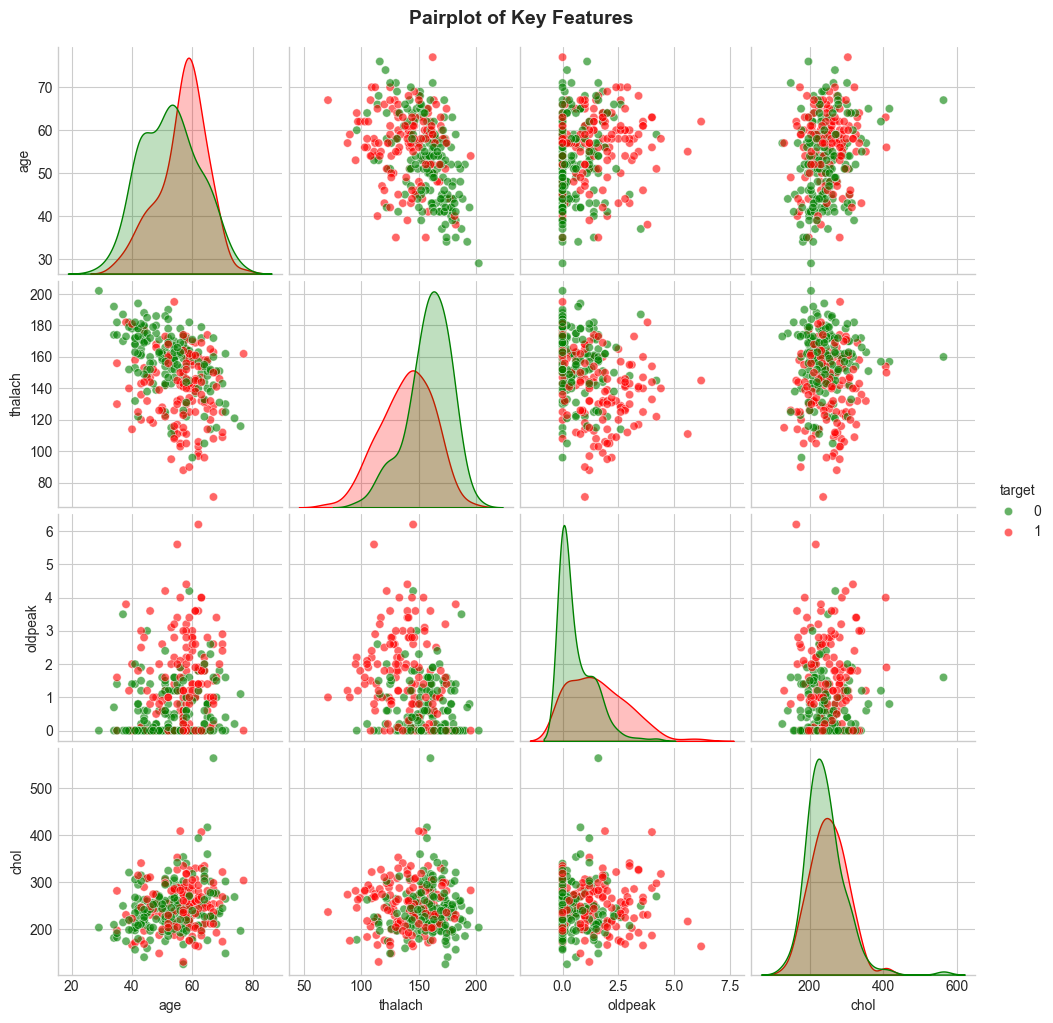

In [21]:
# Pairplot for key features
key_features = ['age', 'thalach', 'oldpeak', 'chol', 'target']
g = sns.pairplot(df[key_features], hue='target', palette={0: 'green', 1: 'red'},
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot of Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('../screenshots/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Insights Summary

In [22]:
# Summary statistics by target class
print('Summary Statistics by Heart Disease Status:')
print('=' * 80)
summary = df.groupby('target')[numerical_features].agg(['mean', 'median', 'std']).round(2)
summary

Summary Statistics by Heart Disease Status:


age              trestbps                  chol                \
         mean median   std     mean median    std    mean median    std   
target                                                                    
0       52.59   52.0  9.51   129.25  130.0  16.20  242.64  234.5  53.46   
1       56.63   58.0  7.94   134.57  130.0  18.77  251.47  249.0  49.49   

       thalach               oldpeak               
          mean median    std    mean median   std  
target                                             
0       158.38  161.0  19.20    0.59    0.2  0.78  
1       139.26  142.0  22.59    1.57    1.4  1.30

In [23]:
# Print key insights
print('=' * 80)
print('KEY INSIGHTS FROM EDA')
print('=' * 80)

print('''
1. DATASET OVERVIEW:
   - 303 patient records from Cleveland Clinic
   - 13 features (6 numerical, 7 categorical)
   - Binary target: Heart Disease presence/absence

2. MISSING VALUES:
   - 'ca' (vessels colored by fluoroscopy): ~2% missing
   - 'thal' (thalassemia): ~1% missing
   - Handled with median/mode imputation

3. CLASS DISTRIBUTION:
   - Relatively balanced (54% No Disease, 46% Disease)
   - No severe class imbalance requiring special handling

4. KEY CORRELATIONS WITH HEART DISEASE:
   - Positive correlation: cp (chest pain), thalach (max heart rate)
   - Negative correlation: exang (exercise angina), oldpeak, ca, thal
   - Age and sex show moderate correlation

5. FEATURE OBSERVATIONS:
   - Age: Ranges from 29-77 years, mean ~54 years
   - Gender: ~68% male, ~32% female
   - Cholesterol: Some potential outliers (>400)
   - Max heart rate: Lower in disease group

6. RECOMMENDATIONS FOR MODELING:
   - All features appear informative for classification
   - Consider feature scaling for numerical features
   - One-hot encoding for categorical features
   - No severe outliers requiring removal
''')

print('=' * 80)

KEY INSIGHTS FROM EDA

1. DATASET OVERVIEW:
   - 303 patient records from Cleveland Clinic
   - 13 features (6 numerical, 7 categorical)
   - Binary target: Heart Disease presence/absence

2. MISSING VALUES:
   - 'ca' (vessels colored by fluoroscopy): ~2% missing
   - 'thal' (thalassemia): ~1% missing
   - Handled with median/mode imputation

3. CLASS DISTRIBUTION:
   - Relatively balanced (54% No Disease, 46% Disease)
   - No severe class imbalance requiring special handling

4. KEY CORRELATIONS WITH HEART DISEASE:
   - Positive correlation: cp (chest pain), thalach (max heart rate)
   - Negative correlation: exang (exercise angina), oldpeak, ca, thal
   - Age and sex show moderate correlation

5. FEATURE OBSERVATIONS:
   - Age: Ranges from 29-77 years, mean ~54 years
   - Gender: ~68% male, ~32% female
   - Cholesterol: Some potential outliers (>400)
   - Max heart rate: Lower in disease group

6. RECOMMENDATIONS FOR MODELING:
   - All features appear informative for classification
 

In [24]:
# Save cleaned data for modeling
df.to_csv('../data/heart_disease_cleaned.csv', index=False)
print('Cleaned dataset saved to ../data/heart_disease_cleaned.csv')
print(f'Final dataset shape: {df.shape}')

Cleaned dataset saved to ../data/heart_disease_cleaned.csv
Final dataset shape: (303, 14)


---

## Next Steps

1. **Feature Engineering**: Create preprocessing pipeline with scaling and encoding
2. **Model Training**: Train multiple models (Logistic Regression, Random Forest, XGBoost)
3. **Experiment Tracking**: Use MLflow to track all experiments
4. **Model Selection**: Compare models using cross-validation and select the best one

See notebook `02_model_training.ipynb` for the next steps.